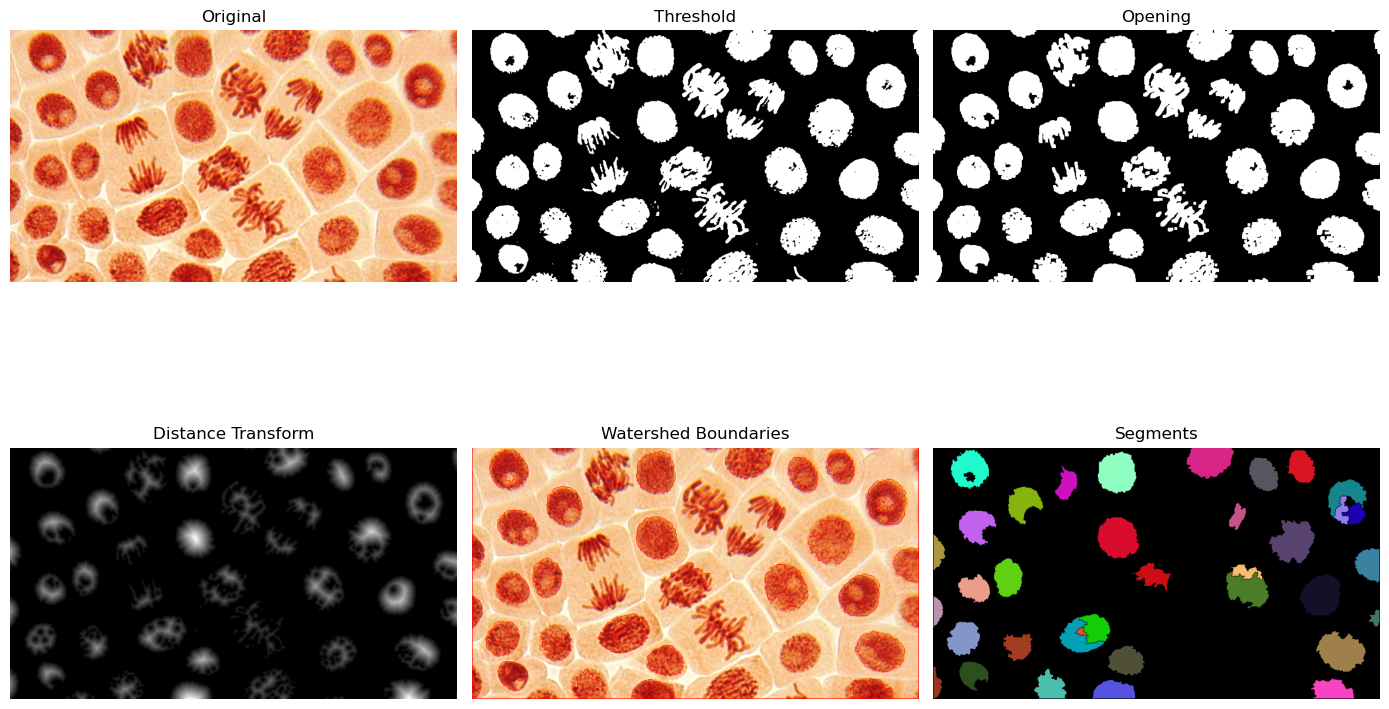

In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


image_path = "1.png"   
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

original = img.copy()

# Converting to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding
_, thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Removing small noise
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure bg area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Sure fg area
# Distance transform highlights object centers
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(
    dist_transform, 0.4 * dist_transform.max(), 255, 0
)

# Converting foreground to uint8
sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Each connected foreground region gets a unique label
num_labels, markers = cv2.connectedComponents(sure_fg)

# Add 1 so background is not 0
markers = markers + 1

# Mark unknown region as 0
markers[unknown == 255] = 0

# 9) Apply watershed
#    Boundary pixels become -1
markers = cv2.watershed(img, markers)

# Draw watershed boundaries in red

result = original.copy()
result[markers == -1] = [0, 0, 255]

# coloring each segment for visualization
segment_vis = np.zeros_like(original)
unique_labels = np.unique(markers)

rng = np.random.default_rng(42)
for label in unique_labels:
    if label <= 1:
        continue
    color = rng.integers(0, 255, size=3, dtype=np.uint8)
    segment_vis[markers == label] = color


plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Threshold")
plt.imshow(thresh, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Opening")
plt.imshow(opening, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("Watershed Boundaries")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("Segments")
plt.imshow(cv2.cvtColor(segment_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()